# PSTAT 134 FINAL PROJECT
- Sid Revanuru
- Jayden Gould
- Jason Kim
- Clark Enge

## Movie Recomender System

## Introduction

This project builds a content-based movie recommender system using metadata from the TMDB (The Movie Database) API. Given a movie title as input, the system identifies and ranks similar films by analyzing content features such as plot overview, genres, cast, and keywords, rather than relying on user ratings or viewing history. The dataset consists of approximately 9,960 movies collected from the TMDB discovery endpoint, sorted by popularity, and includes each film's title, overview text, genre tags, top five billed cast members, associated keywords, vote average, and popularity score.

To build the recommender, all text-based features for each movie are combined into a single tags field and vectorized using Term Frequency-Inverse Document Frequency (TF-IDF) with a vocabulary of 5,000 features and English stop words removed. Pairwise cosine similarity is then computed across the full dataset to produce a 9,960 × 9,960 similarity matrix. When a title is queried, the system retrieves the 100 most text-similar candidates and re-ranks them using a weighted final score:

$$\text{final\_score} = 0.95 \times \text{text\_similarity} + 0.03 \times \text{popularity} + 0.02 \times \text{vote\_average}$$

The small popularity and vote average weights act as tiebreakers among text-similar films. These weights were tuned after observing that higher popularity values caused well-known but thematically unrelated films to dominate results.

### Tech Stack Loading

In [12]:
import os
import time
import pandas as pd
import requests
import ast
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud


In [13]:
cache_file = "all_movie_data"

if os.path.exists(cache_file):
    movies_df = pd.read_pickle(cache_file)

else:
    API_TOKEN = "" # Replace with API token if generating data
    headers = {
        "accept": "application/json",
        "Authorization": f'Bearer {API_TOKEN}'
    }
    movie_data = []
    for page in range(1, 501):
        url = f"https://api.themoviedb.org/3/discover/movie?sort_by=popularity.desc&page={page}"
        response = requests.get(url, headers=headers)
        data = response.json()

        if "results" in data:
            for movie in data['results']:
                movie_id=movie['id']

                details_url = f"https://api.themoviedb.org/3/movie/{movie_id}?append_to_response=credits,keywords"
                details_response = requests.get(details_url, headers=headers)
                details_data = details_response.json()

                movie_dict = {
                    "id": movie_id,
                    'title': details_data['title'],
                    'overview': details_data['overview'],
                    'genres': [genre['name'] for genre in details_data.get('genres', [])],
                    'keywords': [kw['name'] for kw in details_data.get('keywords', {}).get('keywords', [])],
                    'cast': [actor['name'] for actor in details_data.get('credits', {}).get('cast', [])[:5]],
                    'vote_average': details_data['vote_average'],
                    'popularity': details_data['popularity']
                }

                movie_data.append(movie_dict)

                time.sleep(.10)

    movies_df = pd.DataFrame(movie_data)

    movies_df.to_pickle(cache_file)

# Remove duplicate TMDB entries that may have been fetched more than once
movies_df.drop_duplicates(subset='id', keep='first', inplace=True)
movies_df.reset_index(drop=True, inplace=True)
movies_df.head()

,id,title,overview,genres,keywords,cast,vote_average,popularity
0,1226863,The Super Mario Galaxy Movie,Having thwarted Bowser's previous plot to marr...,"[Family, Comedy, Adventure, Fantasy, Animation]","[galaxy, friendship, sibling relationship, spa...","[Chris Pratt, Anya Taylor-Joy, Charlie Day, Ja...",6.732,443.9285
1,1007757,Swapped,"A small woodland creature and a majestic bird,...","[Adventure, Animation, Family, Fantasy]","[wolf, buddy, forest fire, woodlands, loving, ...","[Michael B. Jordan, Juno Temple, Tracy Morgan,...",7.892,409.3611
2,1318447,Apex,A grieving woman pushing her limits on a solo ...,"[Action, Thriller]","[canoe trip, rock climbing, nutcase, survival ...","[Charlize Theron, Taron Egerton, Eric Bana, Ca...",6.417,369.7562
3,10867,Malena,12-year-old Renato experiences three significa...,[Drama],"[prostitute, jealousy, sicily, italy, widow, w...","[Monica Bellucci, Giuseppe Sulfaro, Luciano Fe...",7.429,310.2717
4,1198994,Send Help,Two colleagues become stranded on a deserted i...,"[Horror, Thriller, Comedy]","[bullying, role reversal, survival, struggle f...","[Rachel McAdams, Dylan O'Brien, Edyll Ismail, ...",6.978,247.9714


We want this algorithm to look at large bodies of text instead different strings from different columns, causing the model to jump around. We will now take all of the text-based columns and create a new column combining all of them into one big block of text for each movie to make it easier to read for the computer.

In [14]:
# Helper function
def clean(items):
    return [i.replace(" ", "") for i in items]

# Saves genres
movies_df['genres_display'] = movies_df['genres'].copy()

# Removing spaces form the values in each list column
for col in ['genres', 'cast', 'keywords']:
    movies_df[col] = movies_df[col].apply(clean)

# Turning the overview column into a list of words
movies_df['overview'] = movies_df['overview'].apply(lambda x: x.split() if isinstance(x, str) else [])

# Adding a new column that combines all the lists into one big list with all the information the computer needs
movies_df['tags'] = movies_df['overview'] + movies_df['genres'] + movies_df['cast'] + movies_df['keywords']

# New cleaned df with just the essential information
cleaned_movies_df = movies_df[['id', 'title', 'tags', 'vote_average', 'popularity']].copy()

# Making the giant list a string
cleaned_movies_df['tags'] = cleaned_movies_df['tags'].apply(lambda x: " ".join([str(i) for i in x]) if isinstance(x, list) else "")
# Making all the values in the giant string lowercase
cleaned_movies_df['tags'] = cleaned_movies_df['tags'].apply(lambda x: x.lower())

cleaned_movies_df.head()

,id,title,tags,vote_average,popularity
0,1226863,The Super Mario Galaxy Movie,having thwarted bowser's previous plot to marr...,6.732,443.9285
1,1007757,Swapped,"a small woodland creature and a majestic bird,...",7.892,409.3611
2,1318447,Apex,a grieving woman pushing her limits on a solo ...,6.417,369.7562
3,10867,Malena,12-year-old renato experiences three significa...,7.429,310.2717
4,1198994,Send Help,two colleagues become stranded on a deserted i...,6.978,247.9714


Next, we want to  make it so that the computer is actually able to detect the similarities/differences. To acheive this, we are going to use Term Frequency-Inverse Document Frequency. This counts how many times a word shows up in the tag, but it penalizes words that show up too much.

In [15]:
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

tfidf_matrix = tfidf.fit_transform(cleaned_movies_df['tags'])


The `tfidf_matrix` variable returns a giant matrix of numbers that the computer can read.

Our next step is to scale the continuous variables so that large numbers will not completely break the similarity score.

In [16]:
scaler = MinMaxScaler()

# Scale the continuous variables
cleaned_movies_df[['popularity', 'vote_average']] = scaler.fit_transform(cleaned_movies_df[['popularity', 'vote_average']])

cleaned_movies_df.head()


,id,title,tags,vote_average,popularity
0,1226863,The Super Mario Galaxy Movie,having thwarted bowser's previous plot to marr...,0.6732,1.000000
1,1007757,Swapped,"a small woodland creature and a majestic bird,...",0.7892,0.921934
2,1318447,Apex,a grieving woman pushing her limits on a solo ...,0.6417,0.832491
3,10867,Malena,12-year-old renato experiences three significa...,0.7429,0.698153
4,1198994,Send Help,two colleagues become stranded on a deserted i...,0.6978,0.557455


Now its time to compute the similarity score. We will now calculate the cosine similarity matrix for the text data.

In [17]:
# We want to compare each movie to every other movie
cos_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

print(cos_sim.shape)

(9925, 9925)


## Exploratory Data Analysis

Before building the recommender, we explore the dataset to understand its structure and content.

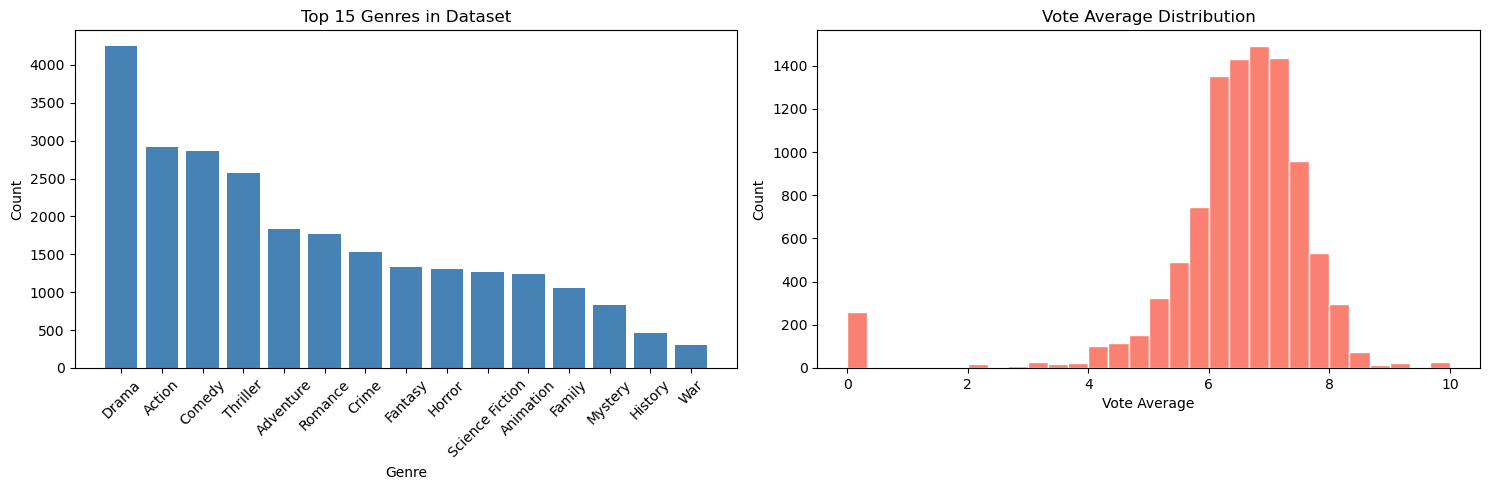

In [18]:
# Plot 1 & 2: Genre distribution and vote average distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

all_genres = movies_df['genres_display'].explode()
genre_counts = all_genres.value_counts().head(15)
axes[0].bar(genre_counts.index, genre_counts.values, color='steelblue')
axes[0].set_title('Top 15 Genres in Dataset')
axes[0].set_xlabel('Genre')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

axes[1].hist(movies_df['vote_average'], bins=30, color='salmon', edgecolor='white')
axes[1].set_title('Vote Average Distribution')
axes[1].set_xlabel('Vote Average')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

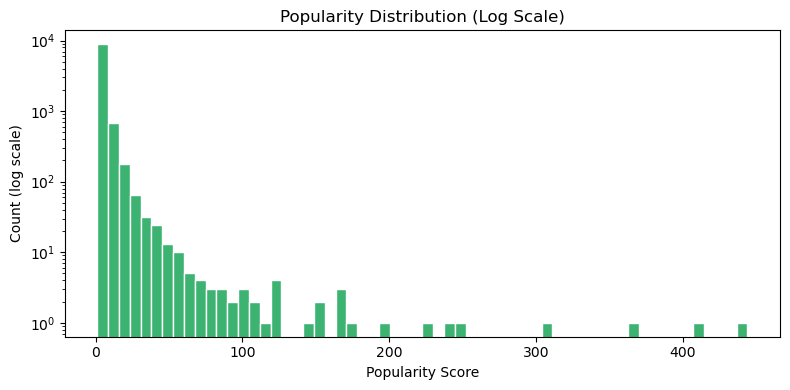

In [19]:
# Plot 3: Popularity distribution (log scale)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(movies_df['popularity'], bins=60, color='mediumseagreen', edgecolor='white')
ax.set_yscale('log')
ax.set_title('Popularity Distribution (Log Scale)')
ax.set_xlabel('Popularity Score')
ax.set_ylabel('Count (log scale)')
plt.tight_layout()
plt.show()

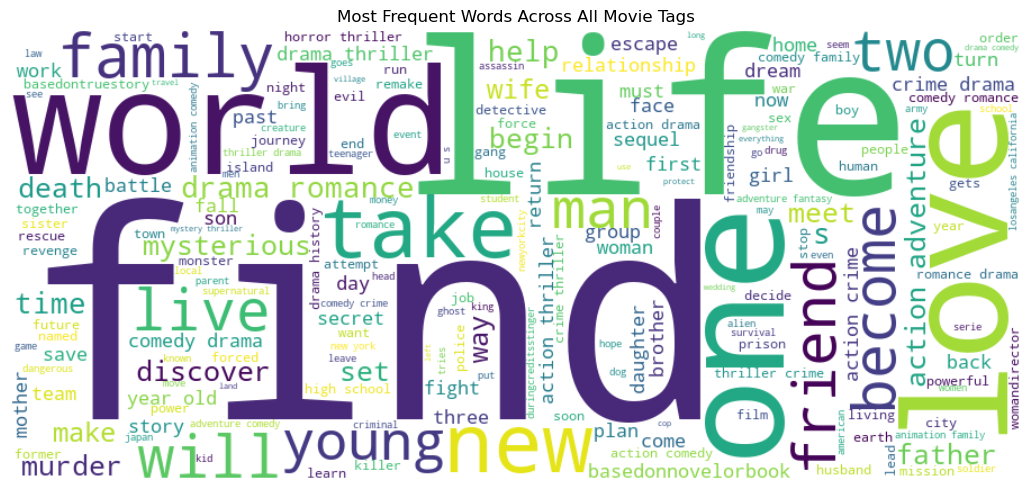

In [20]:
# Plot 4: Word cloud from movie tags
text = ' '.join(cleaned_movies_df['tags'])
wc = WordCloud(width=900, height=400, background_color='white', max_words=200).generate(text)
plt.figure(figsize=(13, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words Across All Movie Tags')
plt.tight_layout()
plt.show()

Now its time to create the recomender function. We want to make the continous variables play a part so we are going to add weights to the popularity and vote_average so that the text similarity isnt the only factor in the recomendation. This way, if two movies are equally similar, the one with the higher popularity would have a higher similarity score.

In [21]:
def recomend(title, text_weight=0.95, pop_weight=0.03, vote_weight=0.02, pool_size=100):
    matches = cleaned_movies_df[cleaned_movies_df['title'].str.lower() == title.lower()]

    if matches.empty:
        print(f'"{title}" was not found in the dataset. Please check the spelling and try again.')
        return

    if len(matches) > 1:
        print(f'Note: {len(matches)} entries found for "{title}". Using the first match (id={matches["id"].iloc[0]}).')

    idx = matches.index[0]
    pos = cleaned_movies_df.index.get_loc(idx)

    # Attach cosine similarity scores
    results = cleaned_movies_df.copy()
    results['cos_sim_score'] = cos_sim[pos]

    # Drop the queried movie, then narrow to the most text-similar movies first
    results = results.drop(index=idx)
    pool = results.nlargest(pool_size, 'cos_sim_score')

    # Rank within that pool using the weighted score
    pool = pool.copy()
    pool['final_score'] = (
        text_weight * pool['cos_sim_score'] +
        pop_weight  * pool['popularity'] +
        vote_weight * pool['vote_average']
    )
    top10 = pool.nlargest(10, 'final_score')

    # Pull original (unscaled) vote_average, popularity, and genres for display
    orig = movies_df.set_index('id')[['vote_average', 'popularity', 'genres_display']]
    top10 = top10.join(orig, on='id', rsuffix='_orig')
    top10['genres_display'] = top10['genres_display'].apply(lambda g: ', '.join(g) if isinstance(g, list) else '')

    output = top10[['title', 'genres_display', 'vote_average_orig', 'popularity_orig', 'final_score']].copy()
    output.columns = ['Title', 'Genres', 'Vote Average', 'Popularity', 'Score']
    output = output.reset_index(drop=True)
    output.index += 1

    return output

In [22]:
recomend("Inception")

,Title,Genres,Vote Average,Popularity,Score
1,Pitch Perfect 2,"Comedy, Music",6.841,6.0127,0.165982
2,The Union,"Action, Comedy",6.079,4.4029,0.163656
3,Spy Kids: All the Time in the World,"Family, Comedy, Action, Adventure",4.697,4.3632,0.159665
4,Snowden,"Drama, History, Crime, Thriller",7.110,3.1820,0.155930
5,Project Power,"Action, Crime, Science Fiction",6.430,2.3493,0.144393
6,Tenet,"Action, Thriller, Science Fiction",7.174,13.3252,0.142606
7,The Saint,"Thriller, Action, Romance, Science Fiction, Ad...",6.104,2.7044,0.139494
8,Pinocchio,"Fantasy, Adventure, Family",6.291,4.2035,0.138713
9,The Walk,"History, Drama, Adventure",6.992,2.5792,0.135663
10,G.I. Joe: The Rise of Cobra,"Adventure, Action, Thriller, Science Fiction",5.782,5.0013,0.134798


## 📋 TODO — Results (WRITE THIS SECTION)

> **Reminder:** Show sample `recomend()` outputs and discuss findings. Key points from testing:
>
> **Inception test findings:**
> - ADD OTHER FINDINGS WITH REAL VALUES
> - With default weights (text=0.95), Tenet appeared at rank 6 in recommendations
> - Some unexpected films appeared (e.g., Pitch Perfect 2) due to coincidental token overlap in TF-IDF space
>
> **Things to discuss:**
> - Show `recomend()` output for 2–3 test titles
> - Do recommendations stay within the same genre? Are they intuitive?
> - How do the weight parameters affect results? (demonstrate with a before/after — original 0.7/0.2/0.1 vs tuned 0.95/0.03/0.02)
> - Note that all expected similar films *were* in the dataset — the issue is TF-IDF similarity strength, not missing data

---

## 💬 TODO — Discussion & Conclusion (WRITE THIS SECTION)

> **Reminder:** Write a 1–2 paragraph conclusion. Key points to cover:
>
> **What was built:** A content-based movie recommender using TF-IDF + cosine similarity on ~9,960 TMDB films, with popularity and vote average as secondary ranking signals.
>
> **Key findings:**
> - The model captures some meaningful similarity — Nolan films (Tenet, Memento) scored highest against Inception
> - Cosine similarity scores are generally low (0.01–0.13 range) because movie overviews are short and use different vocabulary for thematically similar plots
> - Popularity weighting had a large effect: at pop_weight=0.2, irrelevant but popular films dominated; tuning down to 0.03 significantly improved relevance
>
> **Limitations to discuss:**
> - TF-IDF requires exact word overlap — it cannot detect that "dream heist" and "mind-bending sci-fi" are semantically related
> - No user feedback or collaborative signal — two users with different tastes get identical recommendations for the same title
> - Dataset is movies only (despite the project name), and skewed toward recent/popular titles
>
> **Future work:**
> - Sentence embeddings (e.g., BERT, sentence-transformers) to capture semantic meaning rather than exact word frequency
> - Hybrid approach: combine content-based with collaborative filtering using user ratings
> - Expand dataset to include TV shows and older/less popular films

---

## ✅ Pre-Submission Checklist

Before submitting, verify all of the following:

- [x] `recomend()` function is fully implemented and produces correct output
- [ ] Introduction section is written above
- [x] At least **4 visualizations** are present (EDA section)
- [ ] Results section shows sample outputs and discusses findings
- [ ] Discussion & Conclusion section is complete
- [ ] **Kernel → Restart & Run All** — all cells show sequential execution numbers
- [ ] **File → Download as → HTML (.html)** → save as `PSTAT 134 FINAL PROJECT.html` and commit to repo
- [ ] README.md updated with final results summary